In [1]:
## load some packages
import matplotlib.pyplot as plt
from scipy.special import erf
import pandas as pd
import numpy as np
from sklearn_extra.cluster import KMedoids
from sklearn.cluster import KMeans, SpectralClustering, AgglomerativeClustering, DBSCAN
import os
from sklearn.cluster import AgglomerativeClustering
from sklearn_extra.cluster import KMedoids
from sklearn.metrics.cluster import adjusted_rand_score
from sklearn.preprocessing import normalize
import seaborn as sns
import os

In [2]:
def get_cluster_labels(matrix, df, method='h', n_clusters=3, linkage='ward'):
    if method == 'h':
        model = AgglomerativeClustering(n_clusters=n_clusters, linkage=linkage)
    elif method == 'kmed':
        model = KMedoids(n_clusters=n_clusters, random_state=42)
    elif method == 'kmeans':
        model = KMeans(n_clusters=n_clusters, random_state=42)
    elif method == 'spec':
        model = SpectralClustering(n_clusters=n_clusters, affinity='nearest_neighbors', random_state=42)
    elif method == 'db':
        model = DBSCAN(eps=0.5, min_samples=5)
    else:
        raise ValueError("Unsupported clustering method.")
    
    labels = model.fit(matrix).labels_

    df_copy = df.copy()
    df_copy['Cluster'] = labels
    return labels, df_copy

In [3]:
data_dir = "results"
file_list = sorted([f for f in os.listdir(data_dir) if f.endswith(".npy")])
vectorized_data = []

for fname in file_list:
    matrix = np.load(os.path.join(data_dir, fname))
    vector = matrix.flatten()
    
    # Normalize the vector using L2 norm
    norm_vector = normalize(vector.reshape(1, -1), norm='l2')[0]
    vectorized_data.append(norm_vector)

X = np.vstack(vectorized_data)
print("Shape of X:", X.shape)

Shape of X: (129, 16320)


In [4]:
def split_by_dim(X):
    return [
        X[:, 0      : 4080],
        X[:, 4080   : 8160],
        X[:, 8160   : 12240],
        X[:, 12240  : 16320]
    ]

In [5]:
def dimension_normalize(X):
    X_split = split_by_dim(X)
    normed = []
    for Xd in X_split:
        Xd_norm = normalize(Xd, axis=0, norm='l2')
        normed.append(Xd_norm)
    return np.hstack(normed)

In [6]:
X_field = X
X_dim = dimension_normalize(X)

In [7]:
labels = []
label_names = []
X_versions = {'field': X_field, 'dim': X_dim}
methods = ['h', 'kmed', 'kmeans', 'spec', 'db']
dims = ['betti0', 'betti1', 'betti2', 'betti3']

In [8]:
df_betti = pd.DataFrame(X, index=[f.replace(".npy", "") for f in file_list])
matrix_betti = df_betti.values

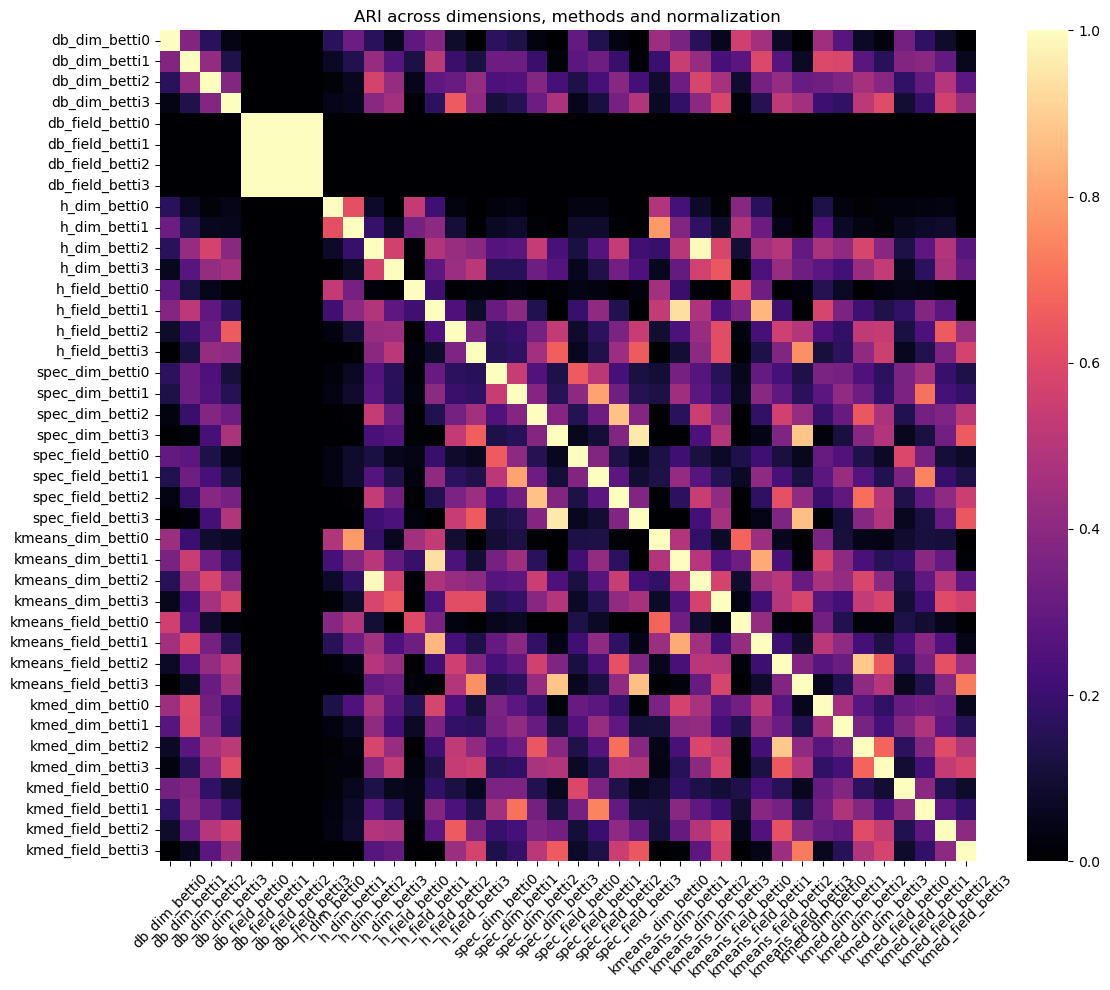

In [9]:
for norm_name, Xmat in X_versions.items():
    X_splits = split_by_dim(Xmat)
    for i, Xd in enumerate(X_splits):
        for method in methods:
            lab, _ = get_cluster_labels(Xd, df_betti, method=method, n_clusters=3)
            labels.append(lab)
            label_names.append(f"{method}_{norm_name}_{dims[i]}")

n = len(labels)
ari_matrix = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        ari_matrix[i, j] = adjusted_rand_score(labels[i], labels[j])

ari_df = pd.DataFrame(ari_matrix, index=label_names, columns=label_names)
ordered_labels = sorted(label_names, key=lambda x: (x.startswith('k'), x))
ari_df = ari_df.loc[ordered_labels, ordered_labels]
plt.figure(figsize=(12, 10))
sns.heatmap(ari_df, annot=False, cmap='magma', vmin=0, vmax=1)
plt.title("ARI across dimensions, methods and normalization")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("ARI_compare_method.png", format='png', bbox_inches='tight')
plt.show()